# 6.4 — Simulación de exposiciones de tasas: puente a XVA

Los tres notebooks anteriores dieron precios de bono y opciones sobre tasas en $t=0$. La gestión de riesgo de contraparte necesita algo distinto: la **distribución** del valor de un swap en cada fecha futura, bajo el modelo ya calibrado — el insumo crudo de cualquier cálculo de CVA/XVA (M11). Este notebook simula esa distribución bajo Hull-White y construye los dos perfiles estándar, **Expected Exposure** y **Potential Future Exposure**, cerrando M6.

## 0. Configuración

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from qflib.market import nelson_siegel_df, par_swap_rate
from qflib.mc import mc_estimate
from qflib.plotting import apply_style

apply_style()
rng = np.random.default_rng(42)

a, sigma = 0.05, 0.01
swap_tenor = 5.0
payment_times = np.arange(1.0, swap_tenor + 1.0)
K = par_swap_rate(nelson_siegel_df, payment_times)
print(f"Swap {int(swap_tenor)}Y par rate = {K:.6%}")
print(f"Hull-White: a={a}, sigma={sigma}")

Swap 5Y par rate = 4.500773%
Hull-White: a=0.05, sigma=0.01


## 1. Exposición: por qué la asimetría $\max(V,0)$ es la cantidad que importa

Un swap valuado hoy vale cero (es la definición de tasa par). Pero gestionar riesgo de contraparte exige algo distinto: si la contraparte incumple en una fecha futura, sólo importa el valor del swap **cuando ese valor favorece a quien mide la exposición** — si el swap está en contra, la pérdida es simplemente el swap perdido, no hay exposición adicional al incumplimiento. De ahí la definición:
$$
EE(t) = \mathbb{E}^{\mathbb{Q}}\big[\max(V(t),0)\big], \qquad PFE_\alpha(t) = \inf\{x:\ \mathbb{Q}(V(t)\leq x)\geq\alpha\}.
$$
La asimetría del `max` es estructural: aunque $\mathbb{E}[V(t)]$ pueda ser cero o negativo, $EE(t)=\mathbb{E}[\max(V(t),0)]$ es **siempre no negativo**, y estrictamente positivo en cuanto $V(t)$ tiene alguna dispersión — la opcionalidad de "sólo cuento cuando me favorece" es lo que hace que un swap sin colateral tenga costo de capital aunque su valor de mercado hoy sea cero.

Valuar $V(t)$ en cada fecha simulada usa los bonos Hull-White cerrados de 6.1 (no una simulación anidada): dado $r_t$ en la fecha de simulación, el valor del swap remanente es $\big(1-P^{HW}(t,T_n;r_t)\big) - K\sum_i\tau_iP^{HW}(t,T_i;r_t)$ — la misma fórmula de tasa par de 5.1/5.5, evaluada con la curva **condicional** en $r_t$ en vez de la curva de hoy.

In [2]:
def instantaneous_forward(t, eps=1e-6):
    '''f^M(0,t), central difference (6.1 Section 4).'''
    t = max(t, 1e-6)
    return (np.log(nelson_siegel_df(t - eps)) - np.log(nelson_siegel_df(t + eps))) / (2.0 * eps)


def hull_white_bond(t, T, r_t, a, sigma):
    '''Hull-White bond price via the market curve (6.1 Section 4).'''
    B = (1.0 - np.exp(-a * (T - t))) / a
    f0t = instantaneous_forward(t)
    return ((nelson_siegel_df(T) / nelson_siegel_df(t))
            * np.exp(B * f0t - sigma**2 / (4 * a) * B**2 * (1.0 - np.exp(-2 * a * t)))
            * np.exp(-B * r_t))


def swap_value_remaining(t, r_t, K, all_payment_times, a, sigma):
    '''PV at t of the remaining cashflows of a receive-float/pay-fixed swap (Section 1).'''
    remaining = all_payment_times[all_payment_times > t + 1e-9]
    if len(remaining) == 0:
        return np.zeros_like(r_t)
    tau = np.diff(np.concatenate([[t], remaining]))
    dfs = np.array([hull_white_bond(t, Ti, r_t, a, sigma) for Ti in remaining])
    float_leg = 1.0 - dfs[-1]
    fixed_leg = K * np.sum(tau[:, None] * dfs, axis=0)
    return float_leg - fixed_leg


v0 = swap_value_remaining(0.0, np.array([instantaneous_forward(1e-6)]), K, payment_times, a, sigma)
print(f"Valor del swap en t=0 (debe ser 0, es la tasa par): {v0[0]:.2e}")

Valor del swap en t=0 (debe ser 0, es la tasa par): -2.78e-17


## 2. Simulación exacta de $r_t$ bajo Hull-White

En vez de discretizar $\theta(t)$ con Euler (que introduce sesgo de discretización *y* exige diferenciar numéricamente la curva dos veces — inestable), simulamos $r_t$ **exacto** usando la descomposición estándar $r_t=x_t+\alpha(t)$ con $x_t$ un proceso de Ornstein-Uhlenbeck **puro** ($dx_t=-ax_tdt+\sigma dW_t$, $x_0=0$, ya derivado en 1.4/6.1) y $\alpha(t)$ un desplazamiento determinista. La convexidad de $e^{-\int r_sds}$ exige que $\alpha(t)$ no sea simplemente $f^M(0,t)$: por Jensen, $\mathbb{E}[e^{-I_t}]=e^{\frac12\text{Var}(I_t)}\neq1$ para $I_t=\int_0^tx_sds$ (que es Gaussiana centrada), así que hay que restar esa convexidad de $\alpha(t)$ para que $\mathbb{E}[e^{-\int_0^tr_sds}]$ siga reproduciendo $P^M(0,t)$ exactamente:
$$
\alpha(t) = f^M(0,t) + \frac{\sigma^2}{2a^2}\big(1-e^{-at}\big)^2, \qquad
\int_0^t\alpha(s)ds = -\ln P^M(0,t) + \tfrac12\text{Var}(I_t).
$$
$(x_t,I_t)$ son conjuntamente Gaussianas con momentos cerrados (varianza/covarianza de un OU y su integral, cálculo directo de Itô):
$$
\text{Var}(x_t)=\frac{\sigma^2}{2a}(1-e^{-2at}), \quad
\text{Var}(I_t)=\frac{\sigma^2}{a^2}\Big(t-\frac2a(1-e^{-at})+\frac1{2a}(1-e^{-2at})\Big), \quad
\text{Cov}(x_t,I_t)=\frac{\sigma^2}{2a^2}(1-e^{-at})^2,
$$
así que se pueden muestrear exactamente (Cholesky de la matriz $2\times2$) sin ningún paso de tiempo — cero sesgo de discretización, y la validación de esta sección es la comprobación de que **el bono simulado reproduce el bono de mercado exactamente**, la identidad más básica de no-arbitraje.

In [3]:
def ou_exact_joint(a, sigma, t, n_paths, rng):
    '''Exact joint sample of (x_t, I_t=int_0^t x_s ds) for dx=-a*x*dt+sigma*dW, x0=0 (Section 2).'''
    var_x = sigma**2 / (2 * a) * (1.0 - np.exp(-2 * a * t))
    var_I = sigma**2 / a**2 * (t - 2 / a * (1 - np.exp(-a * t)) + 1 / (2 * a) * (1 - np.exp(-2 * a * t)))
    cov_xI = sigma**2 / (2 * a**2) * (1.0 - np.exp(-a * t)) ** 2
    cov = np.array([[var_x, cov_xI], [cov_xI, var_I]])
    L = np.linalg.cholesky(cov)
    Z = rng.standard_normal((n_paths, 2))
    samples = Z @ L.T
    return samples[:, 0], samples[:, 1], var_I


def simulate_short_rate_and_discount(t, a, sigma, n_paths, rng):
    '''Exact r_t and discount factor exp(-int_0^t r_s ds) under Hull-White (Section 2).'''
    x_t, I_t, var_I = ou_exact_joint(a, sigma, t, n_paths, rng)
    alpha_t = sigma**2 / (2 * a**2) * (1.0 - np.exp(-a * t)) ** 2
    r_t = instantaneous_forward(t) + alpha_t + x_t
    integral_alpha = -np.log(nelson_siegel_df(t)) + 0.5 * var_I
    discount = np.exp(-(integral_alpha + I_t))
    return r_t, discount


n_paths_check = 200_000
for t_chk, T_chk in [(2.0, 3.0), (2.0, 5.0)]:
    r_t, disc = simulate_short_rate_and_discount(t_chk, a, sigma, n_paths_check, rng)
    bond_sim = hull_white_bond(t_chk, T_chk, r_t, a, sigma)
    mean_est, se_est, _ = mc_estimate(disc * bond_sim)
    true_bond = nelson_siegel_df(T_chk)
    print(f"E[disc({t_chk})*P({t_chk},{T_chk})] = {mean_est:.6f}+-{3*se_est:.6f}  vs P(0,{T_chk})={true_bond:.6f}  "
          f"z={abs(mean_est-true_bond)/se_est:.3f}")

E[disc(2.0)*P(2.0,3.0)] = 0.879598+-0.000164  vs P(0,3.0)=0.879584  z=0.255
E[disc(2.0)*P(2.0,5.0)] = 0.801908+-0.000278  vs P(0,5.0)=0.801800  z=1.159


## 3. Demo 1 — perfiles de EE y PFE, y el pico característico

Simulamos $r_t$ en una malla de fechas hasta el vencimiento del swap, valuamos el swap remanente en cada una con los bonos cerrados, y construimos $EE(t)$ y $PFE_{95\%}(t)$. La forma esperada — la "joroba" característica de un swap par sin amortizar — es creciente al principio (mientras aún hay muchos flujos inciertos por delante) y decreciente hacia el final (cada vez queda menos swap del cual tener exposición), con el pico en algún punto **estrictamente interior**, nunca en el vencimiento mismo.

Pico de EE(t) en t=2.00  (vencimiento del swap: 5.0)
EE(t=0.25) = 0.008699  |  EE(pico) = 0.017741  |  EE(t=4.95) = 0.000452


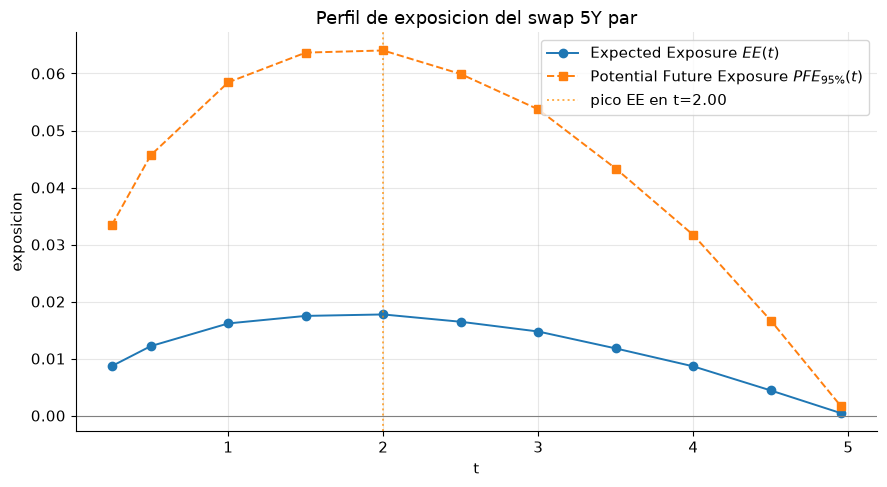

In [4]:
n_paths_profile = 100_000
check_times = np.concatenate([[0.25], np.arange(0.5, swap_tenor, 0.5), [swap_tenor - 0.05]])

EE, PFE95 = [], []
for t_chk in check_times:
    r_t, disc = simulate_short_rate_and_discount(t_chk, a, sigma, n_paths_profile, rng)
    V = swap_value_remaining(t_chk, r_t, K, payment_times, a, sigma)
    EE.append(np.maximum(V, 0.0).mean())
    PFE95.append(np.quantile(V, 0.95))
EE, PFE95 = np.array(EE), np.array(PFE95)

peak_idx = np.argmax(EE)
print(f"Pico de EE(t) en t={check_times[peak_idx]:.2f}  (vencimiento del swap: {swap_tenor})")
print(f"EE(t=0.25) = {EE[0]:.6f}  |  EE(pico) = {EE[peak_idx]:.6f}  |  EE(t={swap_tenor-0.05:.2f}) = {EE[-1]:.6f}")

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(check_times, EE, "o-", label="Expected Exposure $EE(t)$")
ax.plot(check_times, PFE95, "s--", label="Potential Future Exposure $PFE_{95\\%}(t)$")
ax.axhline(0.0, color="gray", lw=0.8)
ax.axvline(check_times[peak_idx], color="darkorange", ls=":", alpha=0.7, label=f"pico EE en t={check_times[peak_idx]:.2f}")
ax.set_xlabel("t"); ax.set_ylabel("exposicion")
ax.set_title(f"Perfil de exposicion del swap {int(swap_tenor)}Y par")
ax.legend()
plt.tight_layout()
plt.show()

## 4. Validación

1. **Valor en $t=0$**: exactamente cero (es la definición de tasa par), sin ruido de simulación porque en $t=0$ no hay incertidumbre.
2. **Martingala del bono**: $\mathbb{E}[\text{disc}(t)P(t,T)]=P(0,T)$ para varios $(t,T)$, dentro de 3 SE — la identidad de no-arbitraje más básica, y la que de verdad certifica que la simulación de $r_t$ (Sección 2) es correcta. (No se valida "$\mathbb{E}[\text{disc}(t)V(t)]=0$" para $t>0$: esa igualdad es falsa en general — hay flujos de caja entre $0$ y $t$ que la rompen; sólo en $t=0$, sin flujos previos, el valor esperado descontado coincide con el valor de hoy.)
3. **$EE(t)\geq0$ en toda la malla**: por construcción del `max`, debe cumplirse siempre, sin excepción.
4. **El pico de $EE(t)$ es interior**: ocurre estrictamente antes del vencimiento del swap, nunca en él ni al principio.

In [5]:
# 1. Valor en t=0
print(f"V(0) = {v0[0]:.2e} (atol 1e-9? {abs(v0[0]) < 1e-9})")
assert abs(v0[0]) < 1e-9

# 2. Martingala del bono
for t_chk, T_chk in [(1.0, 4.0), (2.0, 3.0), (3.0, 5.0)]:
    r_t, disc = simulate_short_rate_and_discount(t_chk, a, sigma, n_paths_check, rng)
    bond_sim = hull_white_bond(t_chk, T_chk, r_t, a, sigma)
    mean_est, se_est, _ = mc_estimate(disc * bond_sim)
    true_bond = nelson_siegel_df(T_chk)
    z = abs(mean_est - true_bond) / se_est
    print(f"  (t={t_chk},T={T_chk}): z = {z:.3f} (<=3? {z <= 3.0})")
    assert z <= 3.0

# 3. EE no negativo
print(f"\nEE(t) >= 0 en toda la malla? {np.all(EE >= 0.0)}")
assert np.all(EE >= 0.0)

# 4. Pico interior
print(f"pico de EE en t={check_times[peak_idx]:.2f}, estrictamente antes del vencimiento ({swap_tenor})? "
      f"{check_times[peak_idx] < swap_tenor}")
assert 0.0 < check_times[peak_idx] < swap_tenor

print()
print("Validacion completa: 4/4 dentro de tolerancia.")

V(0) = -2.78e-17 (atol 1e-9? True)
  (t=1.0,T=4.0): z = 2.570 (<=3? True)
  (t=2.0,T=3.0): z = 0.438 (<=3? True)
  (t=3.0,T=5.0): z = 0.136 (<=3? True)

EE(t) >= 0 en toda la malla? True
pico de EE en t=2.00, estrictamente antes del vencimiento (5.0)? True

Validacion completa: 4/4 dentro de tolerancia.


## Referencias

- Green, A. (2015). *XVA: Credit, Funding and Capital Valuation Adjustments*, Wiley, cap. 6 (definiciones de exposición, EE, PFE).
- Gregory, J. (2015). *The xVA Challenge*, 3rd ed., Wiley, caps. 6-8.
- Brigo, D. & Mercurio, F. (2006). *Interest Rate Models*, 2nd ed., Springer, cap. 3 (la descomposición exacta $r_t=x_t+\alpha(t)$ de Hull-White).